- Normally Distributed : Remove outliers using IQR method (mean +- 3*st. dev)
- Skewed Distribution : Remove outliers using Percentile method boxplot (1st quartile(25th percentile) - 1.5*IQR, 3rd quartile(75th percentile) + 1.5*IQR)

### Importing Libraries and Data

In [221]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

In [222]:
df = pd.read_csv('A:/CODES/PROJECTS/appartments/data/external/gurgaon/properties_cleaned_v2.csv').drop_duplicates()
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,ashiana anmol,sohna road,0.90,9463.0,951.0,Super Built up area 1275(118.45 sq.m.)Carpet a...,2,2,2,13.0,South,Relatively New,1275.0,NaN,951.0,0,0,0,0,0,1,120.0
1,flat,tata primanti,sector 72,3.20,12190.0,2625.0,Super Built up area 2625(243.87 sq.m.)Built Up...,4,4,3+,8.0,North,Moderately Old,2625.0,2600.0,2550.0,0,1,0,0,0,2,168.0
2,flat,supertech araville,sector 79,0.71,5522.0,1286.0,Built Up area: 1295 (120.31 sq.m.),2,2,0,9.0,NaN,Under Construction,NaN,1295.0,NaN,0,0,0,0,0,0,0.0
3,house,anamika enclave,sector 12,6.00,14492.0,4140.0,Plot area 4140(384.62 sq.m.)Built Up area: 900...,9,9,3+,3.0,North-West,Old Property,NaN,9000.0,NaN,0,0,0,0,0,0,9.0
4,flat,shree vardhman flora,sector 90,0.90,4615.0,1950.0,Super Built up area 1950(181.16 sq.m.),3,4,3,4.0,South-West,Relatively New,1950.0,NaN,NaN,0,1,0,0,0,0,165.0


In [223]:
df.shape

(3681, 23)

In [224]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area',
       'study room', 'servant room', 'store room', 'pooja room', 'others',
       'furnishing_type', 'luxury_score'],
      dtype='object')

### price

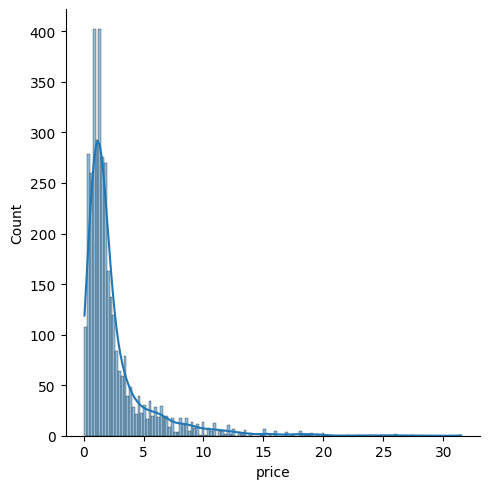

In [225]:
sns.displot(df['price'], kde=True)
# right skewed distribution

<Axes: xlabel='price'>

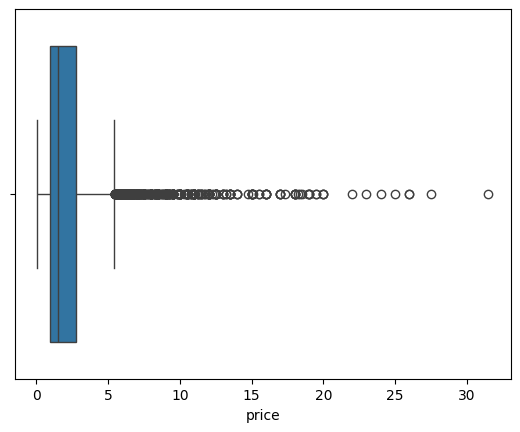

In [226]:
sns.boxplot(x=df['price'])
# It shows there are many outliers above 5 cr. price

In [227]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(425,
 count    425.000000
 mean       9.235624
 std        4.065259
 min        5.460000
 25%        6.460000
 50%        8.000000
 75%       10.750000
 max       31.500000
 Name: price, dtype: float64)

In [228]:
outliers.sort_values('price', ascending=False).head(20)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1273,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7,9,3+,3.0,North-East,Moderately Old,NaN,9000.0,NaN,1,1,1,1,0,1,0.0
1069,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,2,174.0
2202,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,1,0,2,84.0
1763,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,NaN,4545.0,NaN,1,1,0,1,1,2,20.0
1091,house,suncity township,sector 54,25.00,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,North,Moderately Old,NaN,1000.0,NaN,1,1,1,1,0,0,159.0
999,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,1,0,2,44.0
3319,house,independent,sector 26,23.00,25556.0,9000.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,South-West,Relatively New,NaN,9000.0,NaN,1,1,1,1,0,2,144.0
1395,house,vipul tatvam villa,sector 48,22.00,26667.0,8250.0,Plot area 1000(836.13 sq.m.),5,6,3,3.0,NaN,Moderately Old,NaN,1000.0,NaN,0,1,0,0,0,0,160.0
1082,house,dlf city plots,sector 26,20.00,44265.0,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,4.0,North-East,New Property,NaN,4518.0,NaN,1,1,1,1,0,2,33.0
268,house,independent,sector 26,20.00,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,NaN,4500.0,NaN,0,1,0,1,0,1,61.0


In [229]:
# analyzed the outliers and serch actual price on www.99acres.com
# on the basis of price col we can say that there are some genuine outliers but there are some data erros as well

### Price_per_sqft

<Axes: xlabel='price_per_sqft', ylabel='Density'>

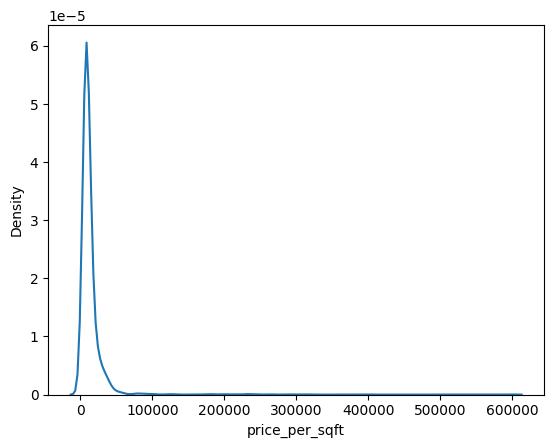

In [230]:
sns.kdeplot(df['price_per_sqft'])

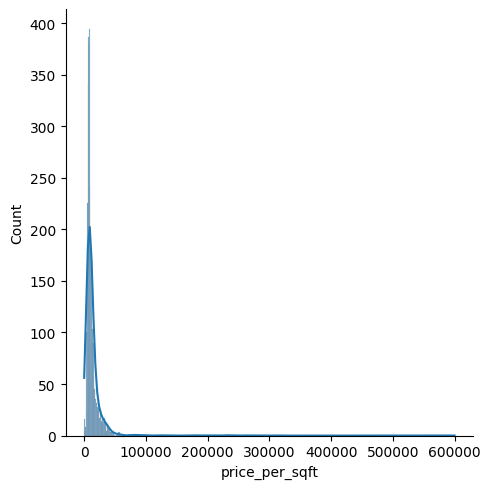

In [231]:
sns.displot(df['price_per_sqft'], kde=True)
# right skewed distribution

<Axes: xlabel='price_per_sqft'>

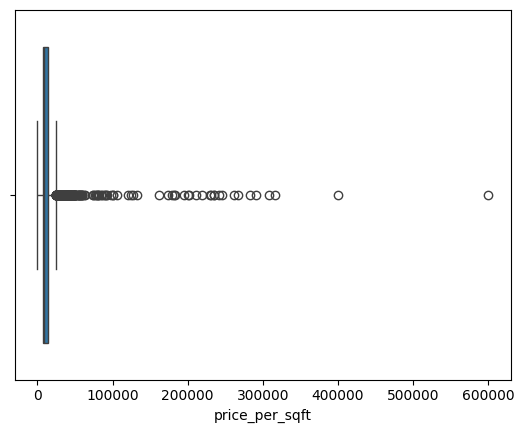

In [232]:
sns.boxplot(x=df['price_per_sqft'])
# It shows there are many outliers above 24489 price_per_sqft

In [233]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(353,
 count       353.000000
 mean      52672.226629
 std       61218.883253
 min       24500.000000
 25%       28233.000000
 50%       33404.000000
 75%       42032.000000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [234]:
# There are certain value under 1000 in sq wards and we yard in sq. ft

In [235]:
#  Converting those values to sq. ft by multiplying with 9 (1 sq. yard = 9 sq. ft) only for outliers
outliers_sqft.loc[:, 'area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

In [236]:
outliers_sqft.loc[:, 'price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

In [237]:
outliers_sqft['price_per_sqft'].describe()
# We can see improvement

count      353.000000
mean     29371.696884
std      12417.964865
min       2723.000000
25%      25562.000000
50%      29880.000000
75%      35556.000000
max      82540.000000
Name: price_per_sqft, dtype: float64

In [238]:
# updating the outliers in the original dataframe
df.update(outliers_sqft)

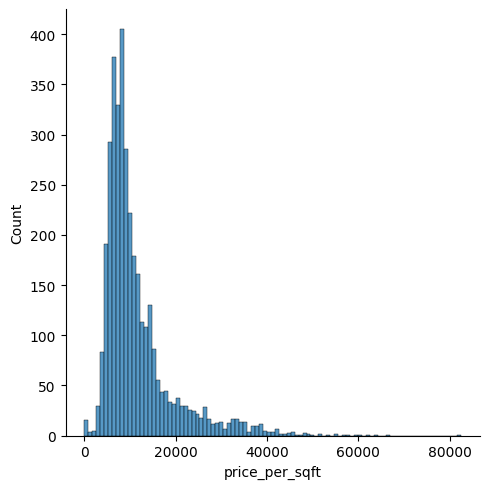

In [239]:
sns.displot(df['price_per_sqft'])
# right skewed distribution has improved but still there are some outliers

<Axes: xlabel='price_per_sqft'>

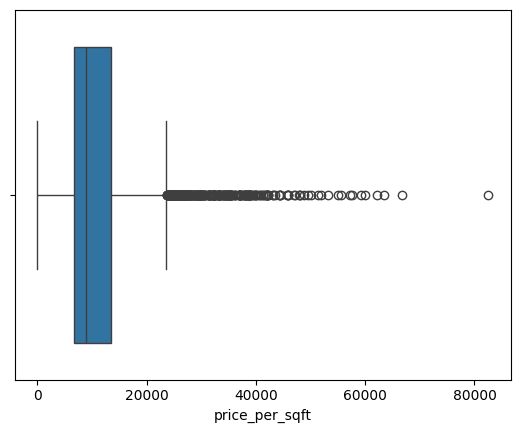

In [240]:
sns.boxplot(x=df['price_per_sqft'])
# Improvemnt is visible here also

In [241]:
df[df['price_per_sqft']>50000]
# Again analyzing the outliers

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
507,house,emaar the palm springs,sector 54,14.00,62222.0,2250.0,Plot area 250(209.03 sq.m.),4,5,3+,2.0,North,Old Property,NaN,2250.0,NaN,1,1,0,0,0,2,66.0
999,house,emaar the palm springs,sector 54,24.00,66667.0,3600.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,1,0,2,44.0
1012,house,independent,sector 26,14.75,51864.0,2844.0,Plot area 316(264.22 sq.m.),16,20,3+,4.0,East,New Property,NaN,2844.0,NaN,1,1,1,1,0,2,58.0
1107,house,malibu towne,sector 47,8.50,53125.0,1600.0,Built Up area: 1600 (148.64 sq.m.),12,12,3+,4.0,North,New Property,NaN,1600.0,NaN,0,0,0,0,0,2,23.0
1705,house,independent,sector 25,16.00,59259.0,2700.0,Plot area 350(292.64 sq.m.)Built Up area: 325 ...,16,16,3+,4.0,West,New Property,NaN,325.0,300.0,1,1,1,1,0,2,105.0
1763,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,NaN,4545.0,NaN,1,1,0,1,1,2,20.0
2202,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,1,0,2,84.0
2327,house,cloudnine cottages,sohna road road,5.50,55000.0,1000.0,Plot area 1000(92.9 sq.m.),3,3,0,1.0,NaN,Moderately Old,NaN,1000.0,NaN,0,0,0,0,0,0,0.0
2612,house,emaar mgf marbella,sector 66,18.00,55556.0,3240.0,Plot area 360(301.01 sq.m.),4,4,3+,3.0,East,Moderately Old,NaN,3240.0,NaN,1,1,0,1,0,1,110.0
2986,flat,unitech vistas,sector 70,9.00,57508.0,1565.0,Built Up area: 1565 (145.39 sq.m.),3,3,0,7.0,NaN,Undefined,NaN,1565.0,NaN,0,0,0,0,0,0,16.0


In [242]:
# Removing those 13 outliers
df = df[df['price_per_sqft'] <= 50000]

<Axes: xlabel='price_per_sqft'>

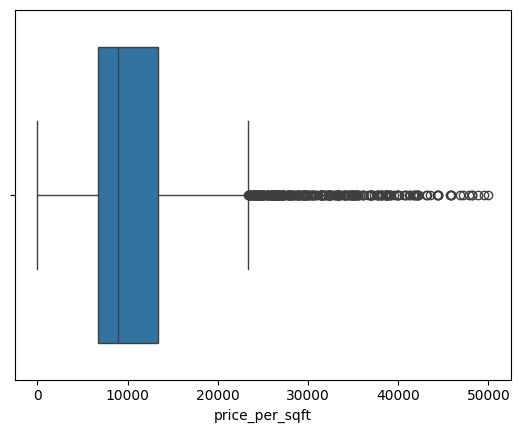

In [243]:
sns.boxplot(x=df['price_per_sqft'])
# more improvement is visible and value came under 50000 price_per_sqft

### Area

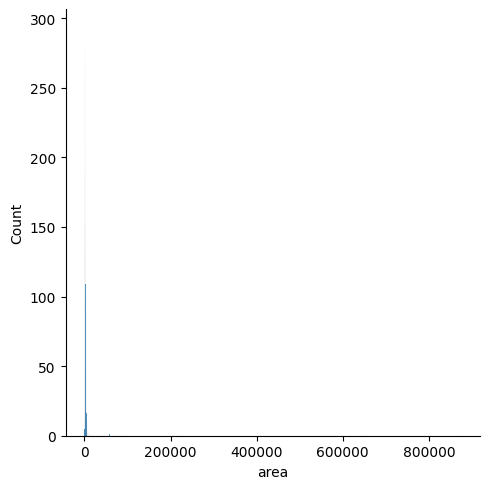

In [244]:
sns.displot(df['area'])
# There are extreme outliers

<Axes: xlabel='area'>

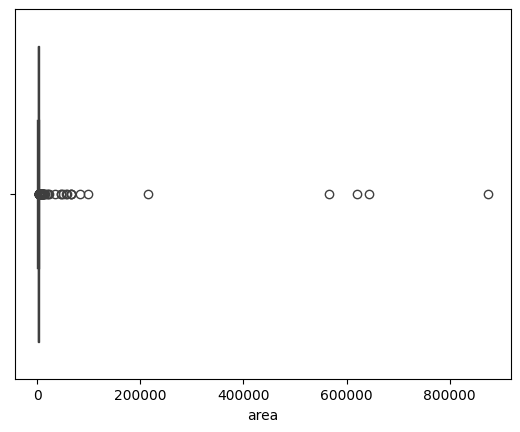

In [245]:
sns.boxplot(x=df['area'])
# There are 5 extreme outliers above 200000

In [246]:
df['area'].describe()
# Maximum value show there are outliers

count      3651.000000
mean       2946.039715
std       23195.534593
min         145.000000
25%        1262.000000
50%        1750.000000
75%        2347.000000
max      875000.000000
Name: area, dtype: float64

In [247]:
df[df['area'] > 100000]
# On Analyzing prices are less in comparison to area

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
311,flat,signature global solera 2,sector 107,0.51,9.0,566667.0,Carpet area: 514396 (47788.95 sq.m.),2,2,1,3.0,North,New Property,NaN,NaN,514396.0,0,0,0,0,0,0,68.0
1329,house,independent,sector 50,5.00,232.0,215517.0,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,New Property,NaN,2.0,NaN,1,1,0,1,1,2,136.0
2622,flat,signature the roselia,sector 95,0.45,7.0,642857.0,Carpet area: 569243 (52884.41 sq.m.),2,2,2,2.0,South-West,New Property,NaN,NaN,569243.0,0,0,0,0,0,0,38.0
3007,flat,ramsons kshitij,sector 95,0.31,5.0,620000.0,Carpet area: 607936 (56479.1 sq.m.),2,2,1,1.0,North-East,Relatively New,NaN,NaN,607936.0,1,0,0,0,1,0,45.0
3255,flat,hcbs sports ville,sohna road,0.35,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2,2,2,8.0,NaN,Relatively New,NaN,737147.0,NaN,0,0,0,0,0,1,50.0


In [248]:
# removing those outliers
df = df[df['area'] < 100000]

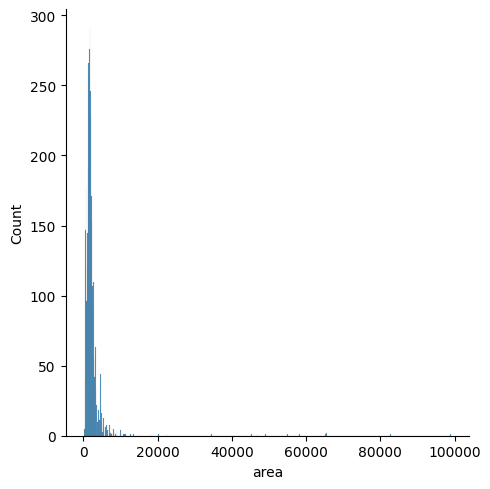

In [249]:
sns.displot(df['area'])
# some change is visible

<Axes: xlabel='area'>

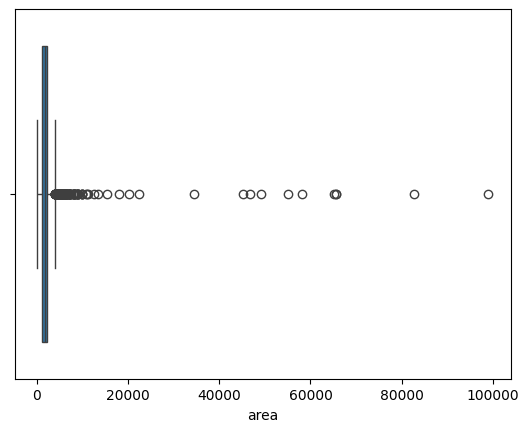

In [250]:
sns.boxplot(x=df['area'])

In [251]:
df[df['area'] > 10000].sort_values('area', ascending=False)

# 818, 1796, 1123, 2, 2356, 115, 3649, 2503, 1471 rows contains errors in typo or data entry

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3545,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.00,0,1,1,1,0,2,49.0
3603,house,ganpati heights apartment,sector 110,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,NaN
1768,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,NaN,NaN,64412.00,0,0,0,0,0,0,165.0
1589,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,NaN,NaN,64529.00,1,0,0,0,0,0,38.0
792,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,0,39.0
1740,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.00,0,0,0,0,0,0,126.0
993,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54917.00,0,0,0,0,0,0,122.0
1568,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.00,1,0,0,0,0,0,54.0
144,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,NaN,5800.0,5200.00,0,1,1,0,0,2,109.0
276,flat,ramsons kshitij,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1,10.0,North-West,Relatively New,NaN,NaN,45966.00,0,0,0,0,1,0,42.0


In [252]:
df.drop(index=[818, 1796, 1123, 2, 2356, 115, 3649, 2503, 1471], inplace=True)
# removing those rows from dataframe

In [253]:
df[df['area'] > 10000].sort_values('area', ascending=False)
# Again analyzing the remaining outliers
# Some are genuine properties but some contain wrong details

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3545,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.00,0,1,1,1,0,2,49.0
3603,house,ganpati heights apartment,sector 110,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,NaN
1768,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,NaN,NaN,64412.00,0,0,0,0,0,0,165.0
1589,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,NaN,NaN,64529.00,1,0,0,0,0,0,38.0
792,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,0,39.0
1740,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.00,0,0,0,0,0,0,126.0
993,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54917.00,0,0,0,0,0,0,122.0
1568,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.00,1,0,0,0,0,0,54.0
144,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,NaN,5800.0,5200.00,0,1,1,0,0,2,109.0
276,flat,ramsons kshitij,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1,10.0,North-West,Relatively New,NaN,NaN,45966.00,0,0,0,0,1,0,42.0


In [254]:
df.loc[48,'area'] = 115*9
df.loc[300,'area'] = 7250
df.loc[2666,'area'] = 5800
df.loc[1358,'area'] = 2660
df.loc[3195,'area'] = 2850
df.loc[2131,'area'] = 1812
df.loc[3088,'area'] = 2160

# correcting area of rows by carpet_area and built_up_area columns

In [255]:
# removing those outliers
df = df[df['area'] < 12000]

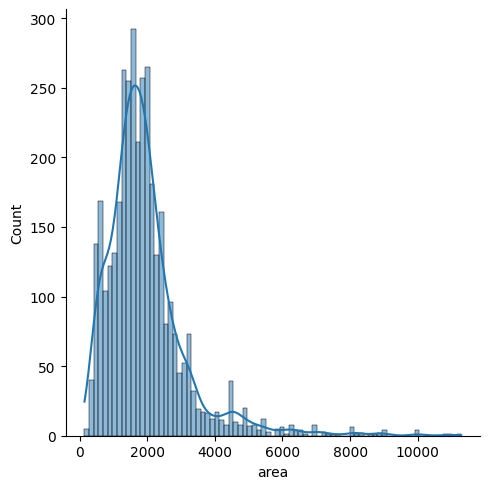

In [256]:
sns.displot(df['area'], kde=True)
# Improvement is visible but there are still some outliers

<Axes: xlabel='area'>

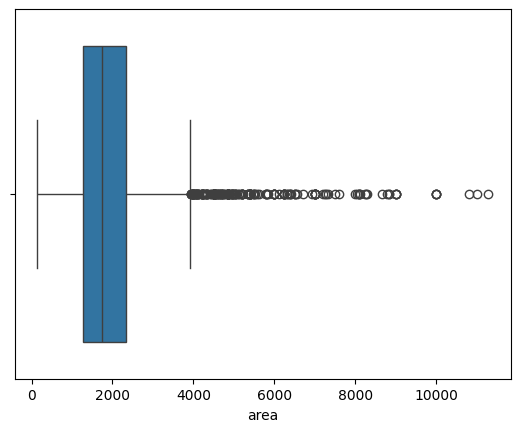

In [257]:
sns.boxplot(x=df['area'])
# Below outliers are genuine properties and not data errors and we are not removing as they will help to find high price properties

In [258]:
df['area'].describe()

count     3621.000000
mean      1951.115438
std       1216.541424
min        145.000000
25%       1261.000000
50%       1747.000000
75%       2325.000000
max      11286.000000
Name: area, dtype: float64

### Bedroom

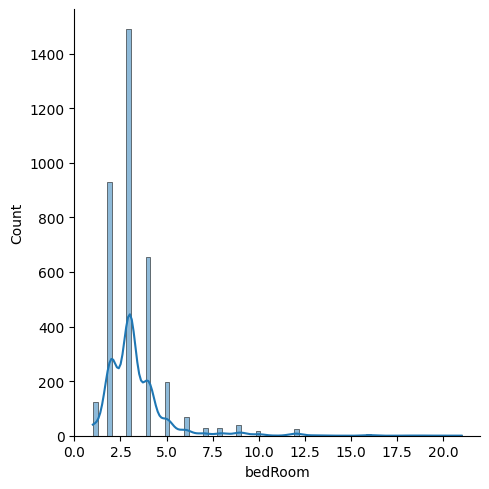

In [259]:
sns.displot(df['bedRoom'], kde=True)
# there are slight outliers and data is right skewed

<Axes: xlabel='bedRoom'>

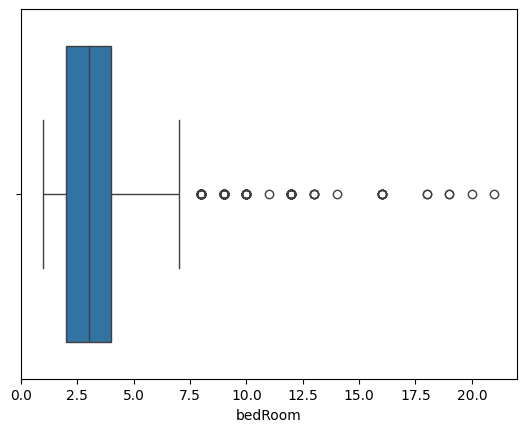

In [260]:
sns.boxplot(x=df['bedRoom'])

In [261]:
df['bedRoom'].describe()

count    3620.000000
mean        3.325414
std         1.819323
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        21.000000
Name: bedRoom, dtype: float64

In [262]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2338,house,independent,sector 54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21.0,21.0,3+,5.0,North,Relatively New,NaN,1161.0,NaN,0.0,1.0,0.0,0.0,0.0,1.0,26.0
399,house,independent,sector 43,4.50,39062.0,1152.0,Plot area 128(107.02 sq.m.),20.0,20.0,3+,4.0,East,Relatively New,NaN,1152.0,NaN,0.0,1.0,0.0,0.0,0.0,1.0,87.0
666,house,independent,sector 17a,3.87,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19.0,17.0,3+,5.0,North-West,Relatively New,NaN,7500.0,NaN,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3209,house,independent,sector 17a,3.93,24214.0,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19.0,17.0,3,4.0,North-West,Relatively New,NaN,1622.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,110.0
3495,house,independent,sector 54,5.50,38194.0,1440.0,Plot area 160(133.78 sq.m.),18.0,18.0,3+,4.0,South-West,Relatively New,NaN,1440.0,NaN,0.0,1.0,0.0,0.0,0.0,1.0,72.0
1814,house,private house,sector 55,7.05,46906.0,1503.0,Plot area 167(139.63 sq.m.),18.0,18.0,3+,4.0,North-East,Relatively New,NaN,1503.0,NaN,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2177,house,luxury dlf city floors,sector 26,20.00,48888.0,4091.0,Plot area 500(418.06 sq.m.),16.0,16.0,3+,4.0,NaN,New Property,NaN,500.0,NaN,0.0,1.0,0.0,0.0,0.0,2.0,49.0
3194,house,independent,sector 55,9.19,34037.0,2700.0,Plot area 300(250.84 sq.m.),16.0,18.0,2,4.0,West,New Property,NaN,2700.0,NaN,0.0,1.0,0.0,1.0,0.0,2.0,28.0
2954,house,independent,sector 56,12.39,45889.0,2700.0,Plot area 300(250.84 sq.m.),16.0,18.0,3+,4.0,North-East,New Property,NaN,2700.0,NaN,0.0,1.0,0.0,1.0,0.0,2.0,174.0
1577,house,independent,sector 40,12.00,38986.0,3078.0,Plot area 342(285.96 sq.m.),16.0,16.0,3+,4.0,NaN,New Property,NaN,3078.0,NaN,1.0,1.0,1.0,1.0,0.0,2.0,63.0


In [263]:
df = df[df['bedRoom'] <= 10]
# I of now i will only use max 10 bed rooms on my application so removing above that

In [264]:
df.shape

(3575, 23)

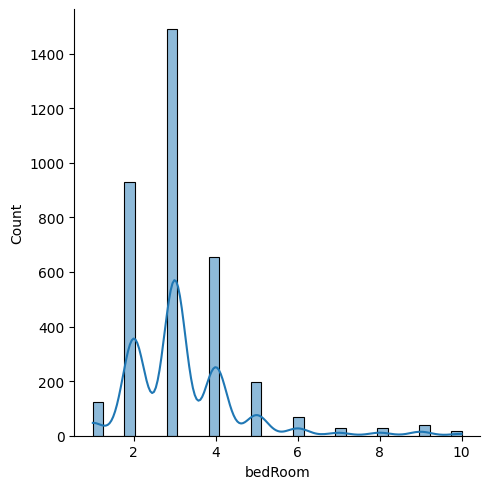

In [265]:
sns.displot(df['bedRoom'], kde=True)
# improvement is visible but there are still some outliers

<Axes: xlabel='bedRoom'>

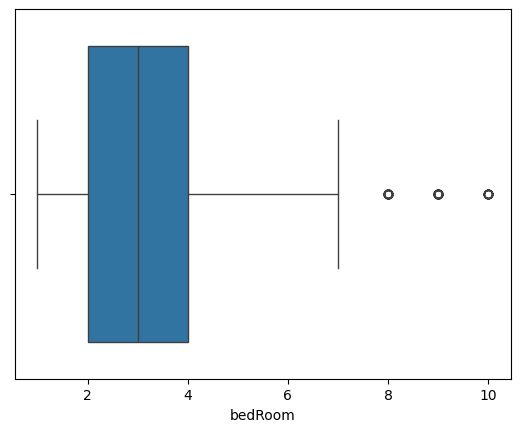

In [266]:
sns.boxplot(x=df['bedRoom'])

In [267]:
df['bedRoom'].describe()

count    3575.000000
mean        3.194965
std         1.377035
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: bedRoom, dtype: float64

### Bathroom

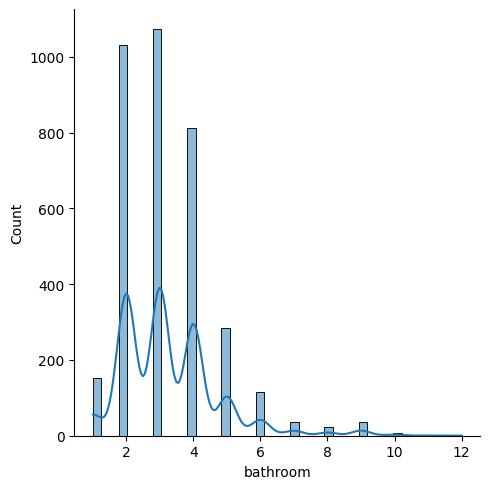

In [268]:
sns.displot(df['bathroom'], kde=True)
# This is also slightly right skewed distribution

<Axes: xlabel='bathroom'>

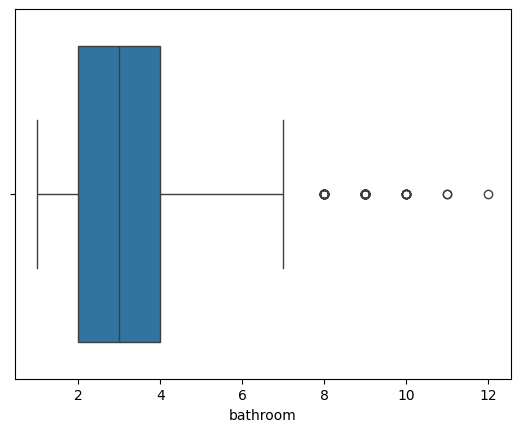

In [269]:
sns.boxplot(x=df['bathroom'])

In [270]:
df[df['bathroom'] > 10].sort_values('bathroom',ascending=False)
# bathroom is not too much high the bedroom so not removing

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3340,house,adani brahma samsara,sector 60,18.02,28200.0,6390.0,Built Up area: 6390 (593.65 sq.m.),9.0,12.0,3+,3.0,North-East,Relatively New,NaN,6390.0,NaN,0.0,1.0,0.0,0.0,0.0,2.0,0.0
1407,house,independent,sector 39,7.00,10000.0,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10.0,11.0,3+,4.0,South-East,Relatively New,NaN,7000.0,NaN,0.0,0.0,0.0,1.0,0.0,2.0,72.0
2004,house,independent,sector 24,11.00,28902.0,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8.0,11.0,3+,3.0,East,Old Property,NaN,5000.0,NaN,1.0,1.0,0.0,1.0,1.0,2.0,0.0


In [271]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,ashiana anmol,sohna road,0.9,9463.0,951.0,Super Built up area 1275(118.45 sq.m.)Carpet a...,2.0,2.0,2,13.0,South,Relatively New,1275.0,NaN,951.0,0.0,0.0,0.0,0.0,0.0,1.0,120.0
1,flat,tata primanti,sector 72,3.2,12190.0,2625.0,Super Built up area 2625(243.87 sq.m.)Built Up...,4.0,4.0,3+,8.0,North,Moderately Old,2625.0,2600.0,2550.0,0.0,1.0,0.0,0.0,0.0,2.0,168.0
3,house,anamika enclave,sector 12,6.0,14492.0,4140.0,Plot area 4140(384.62 sq.m.)Built Up area: 900...,9.0,9.0,3+,3.0,North-West,Old Property,NaN,9000.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,9.0
4,flat,shree vardhman flora,sector 90,0.9,4615.0,1950.0,Super Built up area 1950(181.16 sq.m.),3.0,4.0,3,4.0,South-West,Relatively New,1950.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,165.0
5,flat,vatika city,sector 49,3.6,11920.0,3020.0,Carpet area: 3020 (280.57 sq.m.),4.0,5.0,3,7.0,NaN,Moderately Old,NaN,NaN,3020.0,0.0,1.0,0.0,1.0,0.0,1.0,15.0


### super built up area

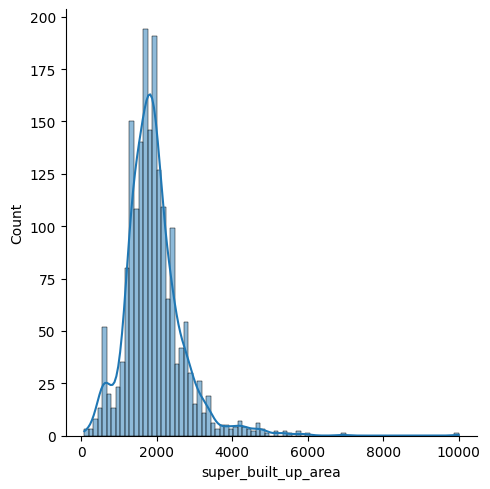

In [272]:
sns.displot(df['super_built_up_area'], kde=True)
# right skewed distribution

<Axes: xlabel='super_built_up_area'>

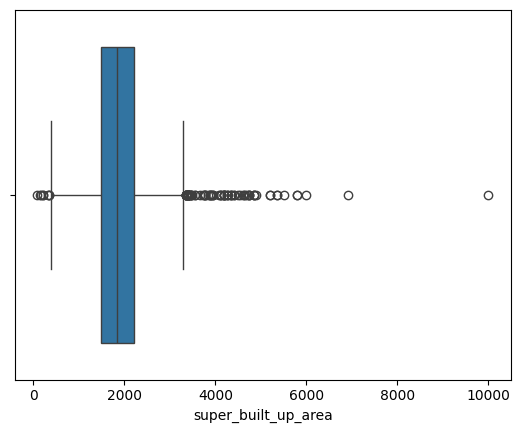

In [273]:
sns.boxplot(x=df['super_built_up_area'])

In [274]:
df['super_built_up_area'].describe()

count     1872.000000
mean      1924.189396
std        765.136416
min         89.000000
25%       1477.250000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [275]:
df[df['super_built_up_area'] > 6000]
# Outliers but looks valid so not removing

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2834,flat,krrish provence estate,gwal pahari,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5.0,6.0,3+,23.0,North-East,Relatively New,10000.0,NaN,NaN,0.0,1.0,0.0,1.0,1.0,0.0,9.0
3113,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4.0,4.0,3+,19.0,North,Relatively New,6926.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,2.0,61.0


### built up area

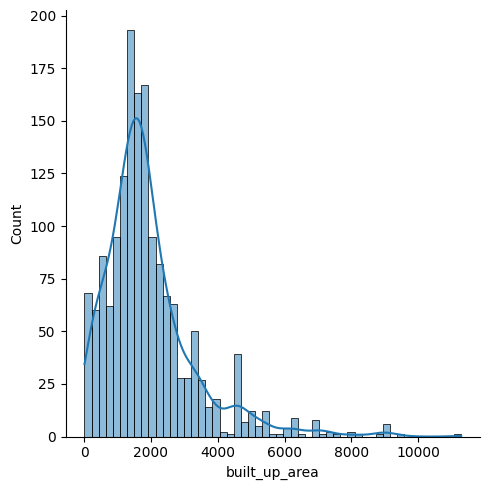

In [276]:
sns.displot(df['built_up_area'], kde=True)
# right skewed distribution

<Axes: xlabel='built_up_area'>

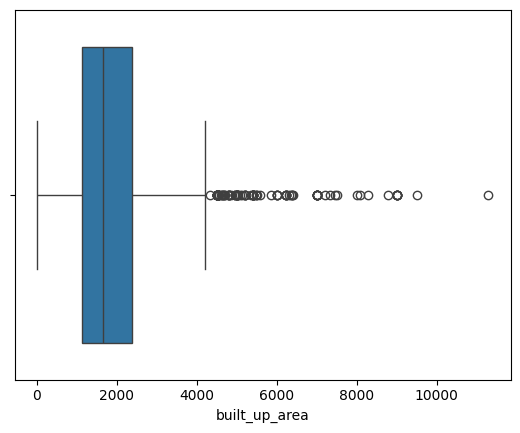

In [277]:
sns.boxplot(x=df['built_up_area'])

In [278]:
df[df['built_up_area'] > 10000]
# outliers but looks valid so not removing

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1069,house,independent,sector 43,27.5,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6.0,7.0,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1.0,1.0,0.0,1.0,1.0,2.0,174.0


### carpet area

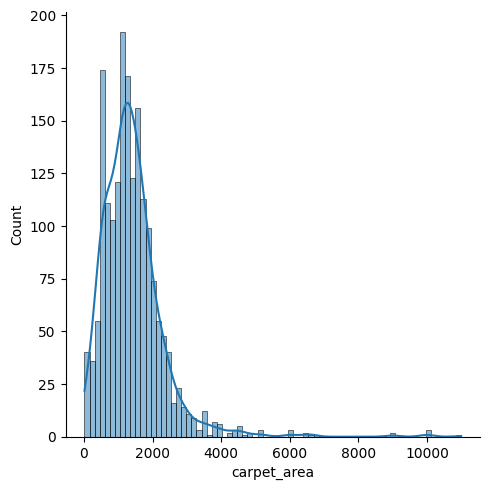

In [279]:
sns.displot(df['carpet_area'], kde=True)
# extremely right skewed distribution

<Axes: xlabel='carpet_area'>

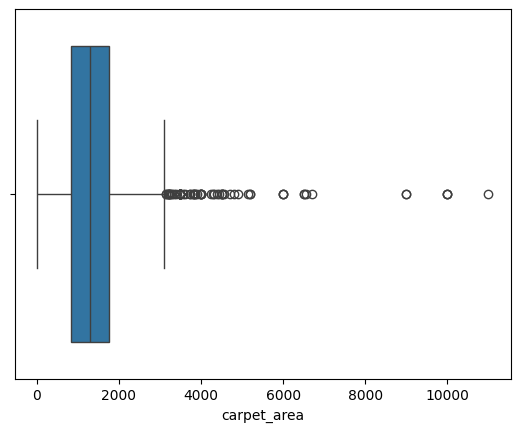

In [280]:
sns.boxplot(x=df['carpet_area'])

In [281]:
df[df['carpet_area'] > 10000]
# Carpet area above 11000 is not valid as price is very less in comparision to area so removing those outliers

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3305,flat,m3m golfestate,sector 65,13.2,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4.0,4.0,3,13.0,North,Moderately Old,NaN,NaN,11000.0,0.0,1.0,0.0,0.0,0.0,0.0,49.0


In [282]:
df.loc[2131,'carpet_area'] = 1812
# correcting the carpet area of row 2131

### luxury_score

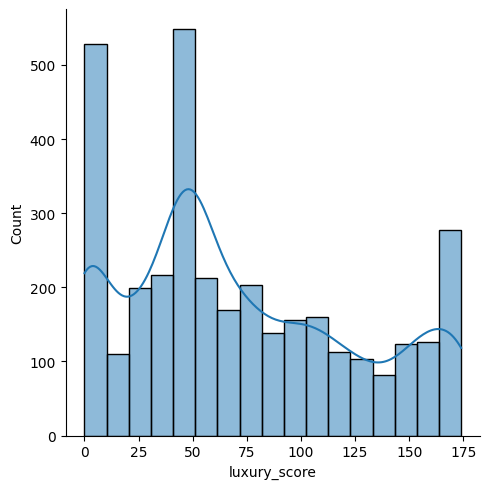

In [283]:
sns.displot(df['luxury_score'], kde=True)
# multiple peaks in distribution

<Axes: ylabel='luxury_score'>

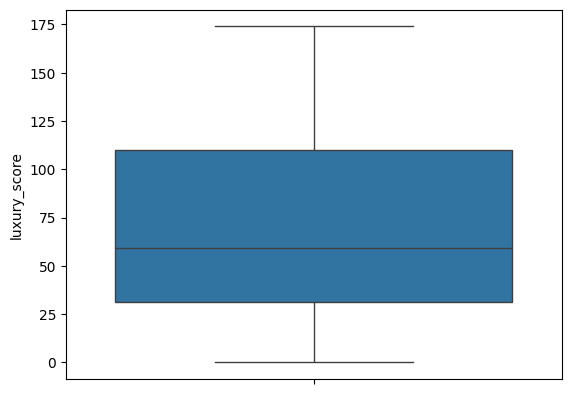

In [284]:
sns.boxplot(df['luxury_score'])
# No outliers in luxury score column

In [285]:
df.shape

(3575, 23)

### Conclusion

In [286]:
# calculating price per sqft again after outlier treatment
df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

In [287]:
df['price_per_sqft'].describe()

count     3575.000000
mean     11277.380699
std       7078.706859
min        544.000000
25%       6755.000000
50%       8897.000000
75%      13281.000000
max      49500.000000
Name: price_per_sqft, dtype: float64

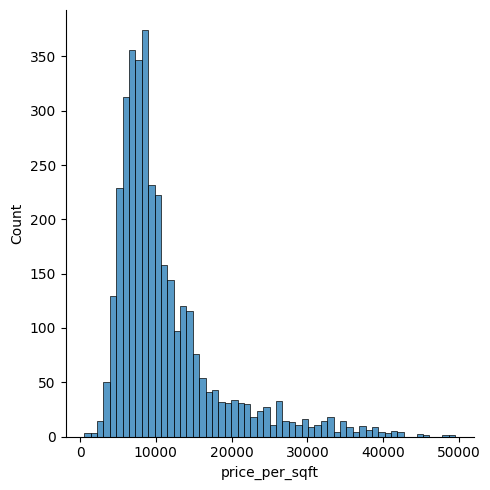

In [288]:
sns.displot(df['price_per_sqft'])
# No big changes in the distribution of price_per_sqft after outlier treatment

<Axes: ylabel='price_per_sqft'>

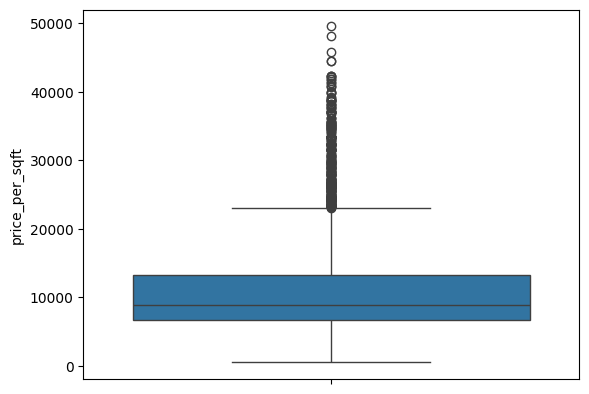

In [289]:
sns.boxplot(df['price_per_sqft'])

In [290]:
# Checking for outliers in price_per_sqft, above 42,000
df[df['price_per_sqft'] > 42000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
214,house,independent,sector 43,9.5,42222.0,2250.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,5.0,5.0,3+,2.0,North-East,Relatively New,NaN,300.0,250.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0
268,house,independent,sector 26,20.0,44444.0,4500.0,Plot area 500(418.06 sq.m.),5.0,7.0,3+,3.0,West,Relatively New,NaN,4500.0,NaN,0.0,1.0,0.0,1.0,0.0,1.0,61.0
949,house,independent,sector 55,5.0,44444.0,1125.0,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9.0,9.0,3+,5.0,East,New Property,NaN,115.0,100.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0
2080,house,independent,sector 28,12.0,42194.0,2844.0,Plot area 316(264.22 sq.m.),4.0,5.0,3+,4.0,East,Relatively New,NaN,2844.0,NaN,0.0,1.0,1.0,1.0,0.0,2.0,152.0
2231,house,independent,sector 26,19.0,42222.0,4500.0,Plot area 500(418.06 sq.m.),6.0,8.0,3+,3.0,East,Moderately Old,NaN,4500.0,NaN,1.0,1.0,1.0,1.0,0.0,2.0,161.0
2270,house,sushant lok 1 builder floors,sector 43,13.0,48148.0,2700.0,Plot area 300(250.84 sq.m.),3.0,3.0,3+,4.0,North,New Property,NaN,2700.0,NaN,0.0,0.0,0.0,1.0,0.0,2.0,128.0
2494,house,dlf city plots,sector 26,19.0,42054.0,4518.0,Plot area 502(419.74 sq.m.),6.0,6.0,3,2.0,East,Relatively New,NaN,4518.0,NaN,1.0,1.0,0.0,0.0,0.0,2.0,93.0
2869,house,independent,sector 105,9.9,49500.0,2000.0,Built Up area: 2000 (185.81 sq.m.)Carpet area:...,2.0,2.0,2,3.0,North,Undefined,NaN,2000.0,1800.0,0.0,0.0,0.0,0.0,0.0,0.0,27.0
3094,house,independent,sector 25,13.0,45710.0,2844.0,Plot area 316(264.22 sq.m.),6.0,8.0,3+,NaN,NaN,Relatively New,NaN,2844.0,NaN,1.0,1.0,1.0,1.0,0.0,1.0,14.0


In [ ]:
# checking for outliers in price_per_sqft, below 20,000 (from above box plot)
x = df[df['price_per_sqft'] <= 20000]
# top 2 percentile of rows where more number of bedRooms in small area such that it is impossible
(x['area']/x['bedRoom']).quantile(0.05)

np.float64(255.26666666666674)

In [ ]:
df[(df['area']/df['bedRoom']) < 250]
# As per analysis there are two scenario
# 1. These records are land and owner wrongly marked it as house, bedroom number is mentioned for multiple floors
# 2. These are actual properties but high number of bedroom is due to multiple floors and area is for one floor only

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
10,house,independent,sector 105,0.60,11111.0,540.0,Plot area 60(50.17 sq.m.),8.0,4.0,3,3.0,West,New Property,NaN,540.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,17.0
23,house,independent,sector 7,1.16,11694.0,992.0,Plot area 992(92.16 sq.m.)Carpet area: 992 sq....,5.0,4.0,2,3.0,North-East,Moderately Old,NaN,NaN,992.000000,0.0,0.0,0.0,0.0,1.0,0.0,39.0
40,flat,pivotal devaan,sector 84,0.36,7595.0,474.0,Super Built up area 583(54.16 sq.m.)Carpet are...,2.0,2.0,1,9.0,West,Relatively New,583.0,NaN,481.000000,0.0,0.0,1.0,0.0,0.0,1.0,80.0
41,house,independent,sector 38,2.10,23333.0,900.0,Plot area 100(83.61 sq.m.),7.0,7.0,3+,3.0,North-East,Relatively New,NaN,900.0,NaN,1.0,0.0,1.0,1.0,0.0,0.0,27.0
43,house,independent,sector 6,0.50,8333.0,600.0,Plot area 600(55.74 sq.m.),3.0,3.0,2,2.0,East,Moderately Old,NaN,600.0,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3609,house,independent,sector 6,0.66,10784.0,612.0,Plot area 612(56.86 sq.m.),3.0,2.0,1,2.0,NaN,Old Property,NaN,612.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3622,house,independent,sector 47,4.30,29312.0,1467.0,Plot area 163(136.29 sq.m.),6.0,4.0,2,2.0,NaN,Moderately Old,NaN,1467.0,NaN,0.0,0.0,0.0,0.0,1.0,0.0,NaN
3633,flat,rof ananda,sector 95,0.37,5745.0,644.0,Carpet area: 644.12 (59.84 sq.m.),3.0,2.0,1,6.0,South-East,Relatively New,NaN,NaN,644.111776,0.0,0.0,0.0,1.0,0.0,2.0,NaN
3636,flat,gls arawali homes,sohna road,0.30,6237.0,481.0,Super Built up area 567(52.68 sq.m.)Carpet are...,2.0,2.0,2,4.0,East,Relatively New,567.0,NaN,480.530000,0.0,0.0,0.0,0.0,0.0,1.0,NaN


In [293]:
df['bedRoom'].value_counts()

bedRoom
3.0     1489
2.0      929
4.0      655
5.0      197
1.0      122
6.0       70
9.0       38
8.0       29
7.0       28
10.0      18
Name: count, dtype: int64

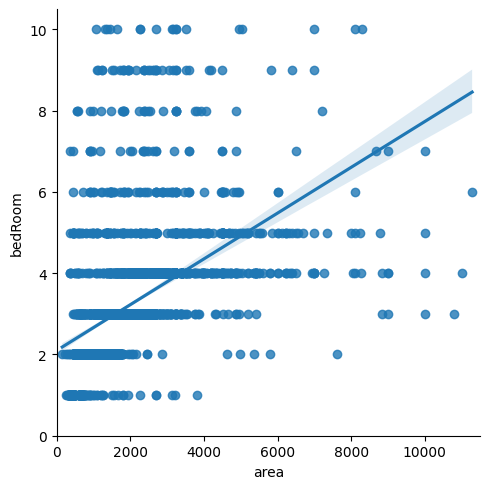

In [294]:
g = sns.lmplot(x='area', y='bedRoom', data=df)
g.set(ylim=(0, 10.5),xlim=(0, 11500))
plt.show()
# we wants to remove the records above line for smaller area

In [295]:
# calculating area to room ratio
df['area_room_ratio'] = df['area']/df['bedRoom']

In [296]:
(df[df['area_room_ratio'] < 250]['bedRoom']).value_counts()

bedRoom
2.0     45
3.0     34
5.0     28
6.0     17
4.0     17
9.0     15
8.0     12
7.0      8
10.0     7
Name: count, dtype: int64

In [297]:
df = df[df['area_room_ratio'] > 100]
# removing the records which have area_room_ratio less than 100 as below 100 is too low

In [298]:
# selecting rows with high number of rooms in small area
outliers_df = df[(df['area_room_ratio'] < 250) & (df['bedRoom'] > 3)]
outliers_df.loc[:, 'bedRoom'] = round(outliers_df['bedRoom']/outliers_df['floorNum'])
df.update(outliers_df)

In [299]:
df['area_room_ratio'] = df['area']/df['bedRoom']
# again calculating area_room_ratio after updating the bedroom number of outliers

In [300]:
df[(df['area_room_ratio'] < 250) & (df['bedRoom'] > 4)]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
53,house,independent,sector 3 phase 2,0.85,9444.0,900.0,Carpet area: 900 (83.61 sq.m.),5.0,3.0,3,1.0,NaN,Undefined,NaN,NaN,900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,180.000000
200,house,independent,sector 2,0.98,9074.0,1080.0,Carpet area: 120 (100.34 sq.m.),9.0,4.0,3,1.0,South,Undefined,NaN,NaN,120.0,0.0,0.0,0.0,0.0,0.0,0.0,33.0,120.000000
242,house,independent,sector 11,3.50,15556.0,2250.0,Built Up area: 2250 (209.03 sq.m.),10.0,1.0,0,1.0,NaN,New Property,NaN,2250.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,21.0,225.000000
598,house,independent,sector 3 phase 2,1.10,10000.0,1100.0,Built Up area: 1100 (102.19 sq.m.)Carpet area:...,5.0,4.0,2,1.0,East,Undefined,NaN,1100.0,900.0,0.0,0.0,0.0,0.0,0.0,0.0,56.0,220.000000
1496,house,"bhim nagar, sector 6",sector 6,0.85,14096.0,603.0,Plot area 67(6.22 sq.m.),5.0,2.0,2,1.0,NaN,Old Property,NaN,67.0,NaN,0.0,0.0,0.0,1.0,0.0,0.0,78.0,120.600000
1604,house,shivpuri,sector 7,2.80,12444.0,2250.0,Plot area 2250(209.03 sq.m.),10.0,7.0,3,1.0,NaN,Old Property,NaN,2250.0,NaN,1.0,1.0,0.0,1.0,1.0,2.0,21.0,225.000000
1649,house,independent,sector 12,2.50,13889.0,1800.0,Plot area 1800(167.23 sq.m.),9.0,5.0,2,1.0,South-East,Old Property,NaN,1800.0,NaN,0.0,0.0,0.0,1.0,0.0,0.0,174.0,200.000000
2175,house,independent,sector 17,0.32,5664.0,565.0,Built Up area: 565 (52.49 sq.m.),5.0,1.0,0,1.0,NaN,Undefined,NaN,565.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,56.0,113.000000
2204,house,independent,sector 12,0.65,6500.0,1000.0,Carpet area: 1000 (92.9 sq.m.),6.0,2.0,3,1.0,NaN,Undefined,NaN,NaN,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,125.0,166.666667
2317,house,independent,sector 7,1.16,11717.0,990.0,Carpet area: 110 (91.97 sq.m.),5.0,4.0,2,1.0,North-East,Undefined,NaN,NaN,110.0,0.0,0.0,0.0,0.0,0.0,0.0,35.0,198.000000


In [301]:
# there are 13 outliers still remaining after above transformation so removing those records as well
df[(df['area_room_ratio'] < 250) & (df['bedRoom'] > 4)].shape

(13, 24)

In [302]:
df.shape

(3555, 24)

In [303]:
df = df[~((df['area_room_ratio'] < 250) & (df['bedRoom'] > 4))]

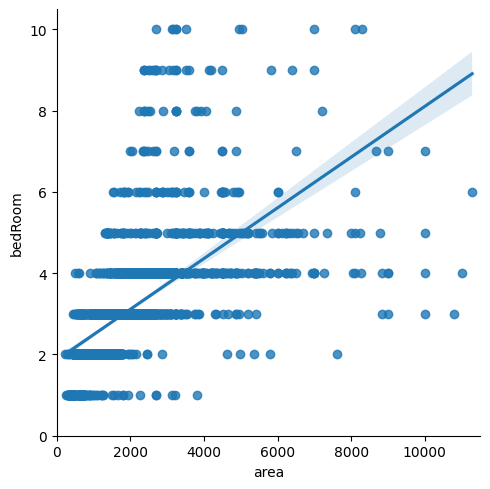

In [304]:
g = sns.lmplot(x='area', y='bedRoom', data=df)
g.set(ylim=(0, 10.5),xlim=(0, 11500))
plt.show()
# after removing the outliers above line for smaller area

In [305]:
df.shape

(3542, 24)

In [306]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,ashiana anmol,sohna road,0.9,9464.0,951.0,Super Built up area 1275(118.45 sq.m.)Carpet a...,2.0,2.0,2,13.0,South,Relatively New,1275.0,NaN,951.0,0.0,0.0,0.0,0.0,0.0,1.0,120.0,475.50
1,flat,tata primanti,sector 72,3.2,12190.0,2625.0,Super Built up area 2625(243.87 sq.m.)Built Up...,4.0,4.0,3+,8.0,North,Moderately Old,2625.0,2600.0,2550.0,0.0,1.0,0.0,0.0,0.0,2.0,168.0,656.25
3,house,anamika enclave,sector 12,6.0,14493.0,4140.0,Plot area 4140(384.62 sq.m.)Built Up area: 900...,9.0,9.0,3+,3.0,North-West,Old Property,NaN,9000.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,9.0,460.00
4,flat,shree vardhman flora,sector 90,0.9,4615.0,1950.0,Super Built up area 1950(181.16 sq.m.),3.0,4.0,3,4.0,South-West,Relatively New,1950.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,165.0,650.00
5,flat,vatika city,sector 49,3.6,11921.0,3020.0,Carpet area: 3020 (280.57 sq.m.),4.0,5.0,3,7.0,NaN,Moderately Old,NaN,NaN,3020.0,0.0,1.0,0.0,1.0,0.0,1.0,15.0,755.00


In [307]:
df.to_csv('A:/CODES/PROJECTS/appartments/data/external/gurgaon/properties_cleaned_v3.csv', index=False)